# Social Media Performance Predictor
## Lighthouse Sanctuary — INTEX W26

---

## 1. Business Understanding

### Problem Statement
Lighthouse Sanctuary’s social media manager needs data-driven guidance on **what to post, when to post it, and on which platform** to maximize donation referrals. Currently, posting decisions are made by intuition, and the organization has no systematic way to evaluate which content strategies drive the most donations.

### Modeling Goal
This pipeline is **primarily predictive with an explanatory component**:
- **Predictive:** Given a set of posting decisions (platform, content type, timing, format), predict how many donation referrals the post will generate.
- **Explanatory:** Identify which factors most strongly drive donation referrals so the social media manager can make informed decisions.

### Target Variable
`donation_referrals` — the count of donation referrals attributed to each social media post. This is a **regression** problem (continuous numeric target).

### Success Metrics
- **MAE and RMSE** on held-out test data, compared against a naive baseline (predicting the mean for every post).
- **Feature importance rankings** that answer the business question: what drives donation referrals?

### Key Constraint: No Data Leakage
We only use features that are **known before a post is published** (platform, content type, timing, etc.). Post-publication engagement metrics (likes, shares, impressions, reach) are outcomes of the post’s performance and cannot be used as predictors.

In [1]:
# If running in Google Colab, uncomment the next two lines:
# from google.colab import drive
# drive.mount("/content/drive")

---

## 2. Data Understanding

This section explores the `social_media_posts` dataset (812 posts across 7 platforms) to understand content patterns, engagement distributions, and relationships between posting decisions and donation referrals.

The dataset is the richest single table in the project — each row captures a complete picture of a social media post from content metadata through engagement metrics and donation attribution. The key analytical challenge is distinguishing **pre-posting decisions** (what the social media manager controls: platform, content type, timing, format) from **post-publication outcomes** (impressions, likes, shares, engagement rate) that are consequences of those decisions. Only pre-posting features can be used as model inputs without introducing data leakage.

In [2]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, RepeatedKFold)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,
                              GradientBoostingRegressor)
from sklearn.inspection import permutation_importance

import joblib
import json
from datetime import datetime, timezone

sns.set_style("whitegrid")
SEED = 42

In [3]:
# ============================================================
# 2a. Load the data
# ============================================================
USE_DATABASE = False  # flip to True once Azure SQL connection string is available

if USE_DATABASE:
    from sqlalchemy import create_engine
    CONNECTION_STRING = ""  # <-- paste Azure SQL connection string here
    engine = create_engine(CONNECTION_STRING)
    df_raw = pd.read_sql("SELECT * FROM social_media_posts", engine)
else:
    DATA_PATH = "../data/social_media_posts.csv"
    df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Shape: (812, 39)
Columns: ['post_id', 'platform', 'platform_post_id', 'post_url', 'created_at', 'day_of_week', 'post_hour', 'post_type', 'media_type', 'caption', 'hashtags', 'num_hashtags', 'mentions_count', 'has_call_to_action', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'caption_length', 'features_resident_story', 'campaign_name', 'is_boosted', 'boost_budget_php', 'impressions', 'reach', 'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views', 'engagement_rate', 'profile_visits', 'donation_referrals', 'estimated_donation_value_php', 'follower_count_at_post', 'watch_time_seconds', 'avg_view_duration_seconds', 'subscriber_count_at_post', 'forwards']


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21,10,21473.25,1522,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335,2,4708.45,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8,0,0.00,457,NaN,NaN,NaN,NaN
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00,Monday,15,ThankYou,Video,Every donation is a prayer answered. Thank you...,...,3313.0,0.0677,62,0,0.00,1796,NaN,NaN,NaN,NaN
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00,Monday,15,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,...,17974.0,0.0802,172,2,8351.49,916,NaN,NaN,NaN,NaN


In [4]:
# ============================================================
# 2b. Structural overview and missingness
# ============================================================
display(df_raw.info())

missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print("\nColumns with missing values:")
display(missing_report[missing_report["missing_count"] > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 812 entries, 0 to 811
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   post_id                       812 non-null    int64  
 1   platform                      812 non-null    object 
 2   platform_post_id              812 non-null    object 
 3   post_url                      812 non-null    object 
 4   created_at                    812 non-null    object 
 5   day_of_week                   812 non-null    object 
 6   post_hour                     812 non-null    int64  
 7   post_type                     812 non-null    object 
 8   media_type                    812 non-null    object 
 9   caption                       812 non-null    object 
 10  hashtags                      664 non-null    object 
 11  num_hashtags                  812 non-null    int64  
 12  mentions_count                812 non-null    int64  
 13  has_c

None


Columns with missing values:


,missing_count,missing_pct
subscriber_count_at_post,741,91.3
avg_view_duration_seconds,741,91.3
watch_time_seconds,741,91.3
forwards,719,88.5
boost_budget_php,685,84.4
campaign_name,580,71.4
video_views,479,59.0
call_to_action_type,319,39.3
hashtags,148,18.2


**Expected missingness:** Platform-specific columns (`video_views`, `watch_time_seconds`, `avg_view_duration_seconds`, `subscriber_count_at_post`, `forwards`) are only populated for their respective platforms (YouTube, WhatsApp). These are not data quality issues — they are structural nulls.

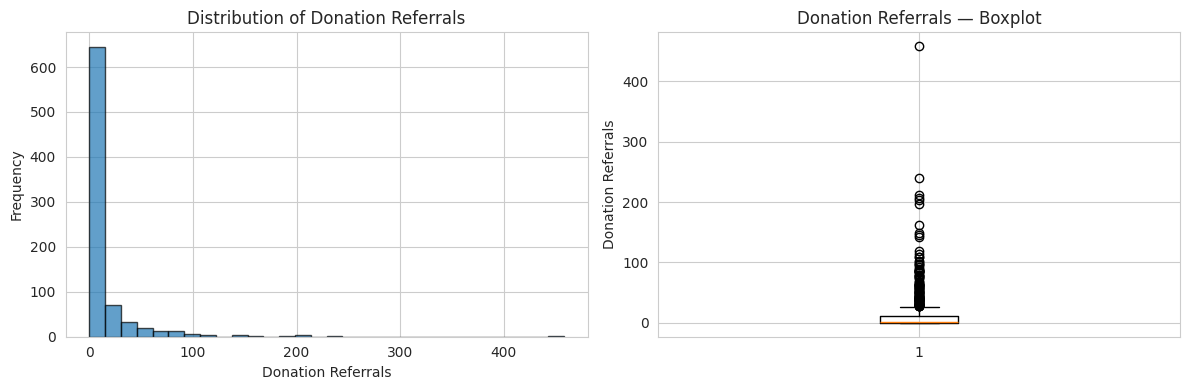

count    812.000000
mean      12.795567
std       31.261714
min        0.000000
25%        0.000000
50%        2.000000
75%       11.000000
max      458.000000
Name: donation_referrals, dtype: float64


In [5]:
# ============================================================
# 2c. Target variable: donation_referrals
# ============================================================
target = "donation_referrals"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw[target], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of Donation Referrals")
axes[0].set_xlabel("Donation Referrals")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df_raw[target], vert=True)
axes[1].set_title("Donation Referrals — Boxplot")
axes[1].set_ylabel("Donation Referrals")

plt.tight_layout()
plt.show()

print(df_raw[target].describe())

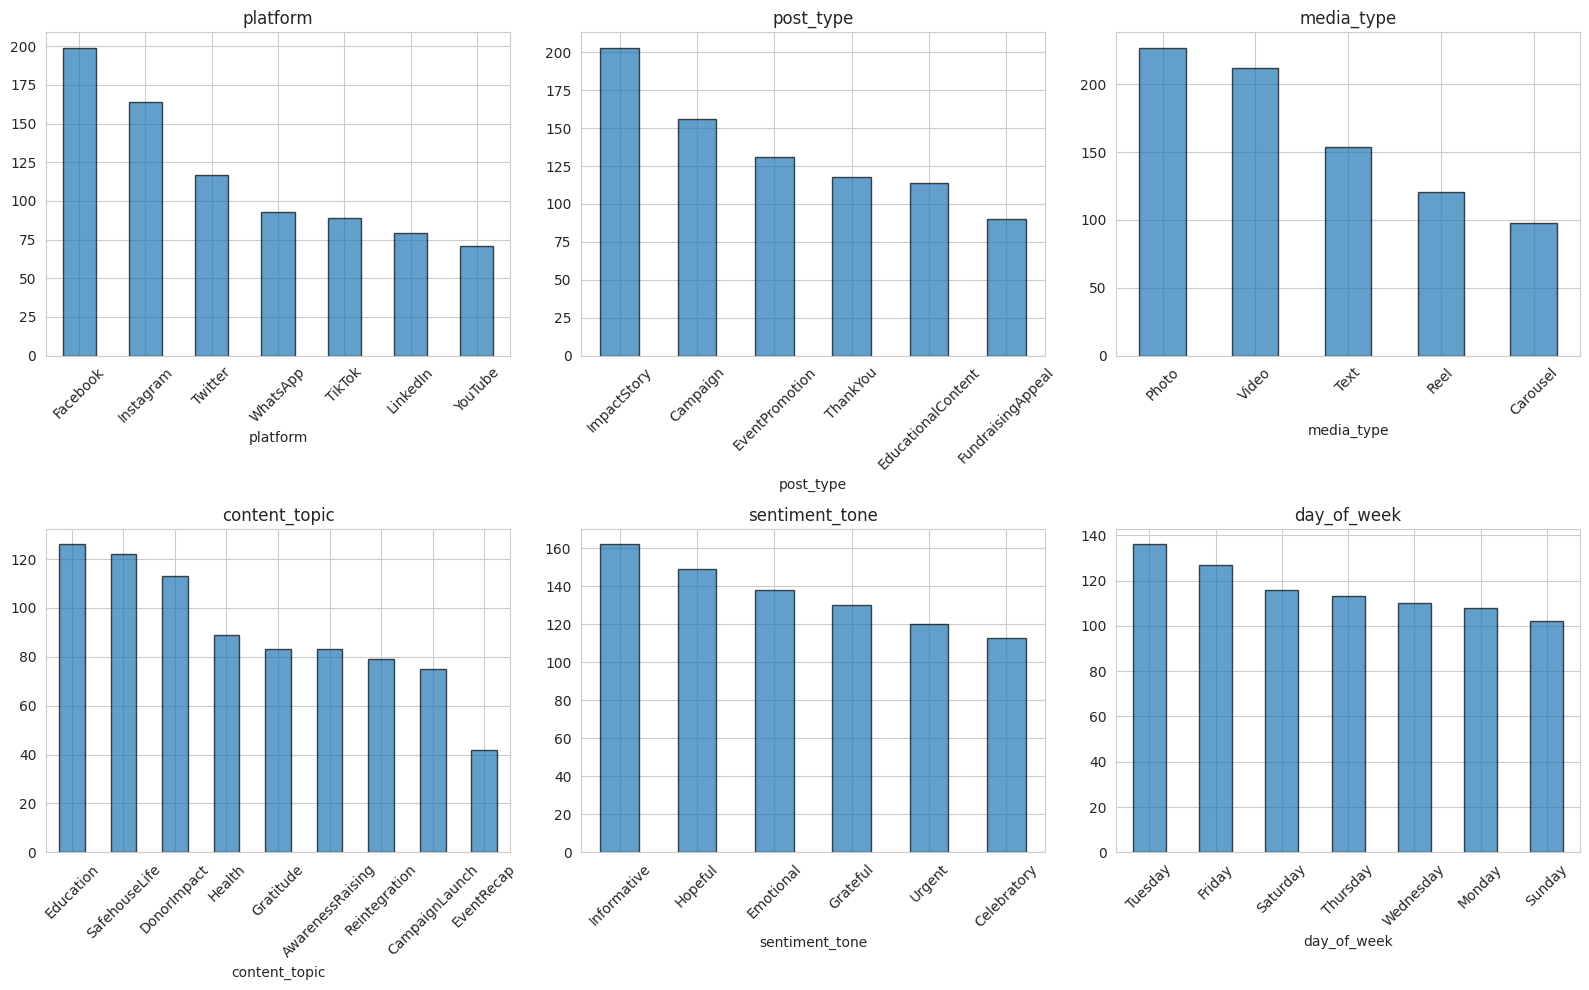

In [6]:
# ============================================================
# 2d. Categorical feature distributions
# ============================================================
cat_features = ["platform", "post_type", "media_type", "content_topic",
                "sentiment_tone", "day_of_week"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    df_raw[col].value_counts().plot(kind="bar", ax=axes[i], edgecolor="black", alpha=0.7)
    axes[i].set_title(f"{col}")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

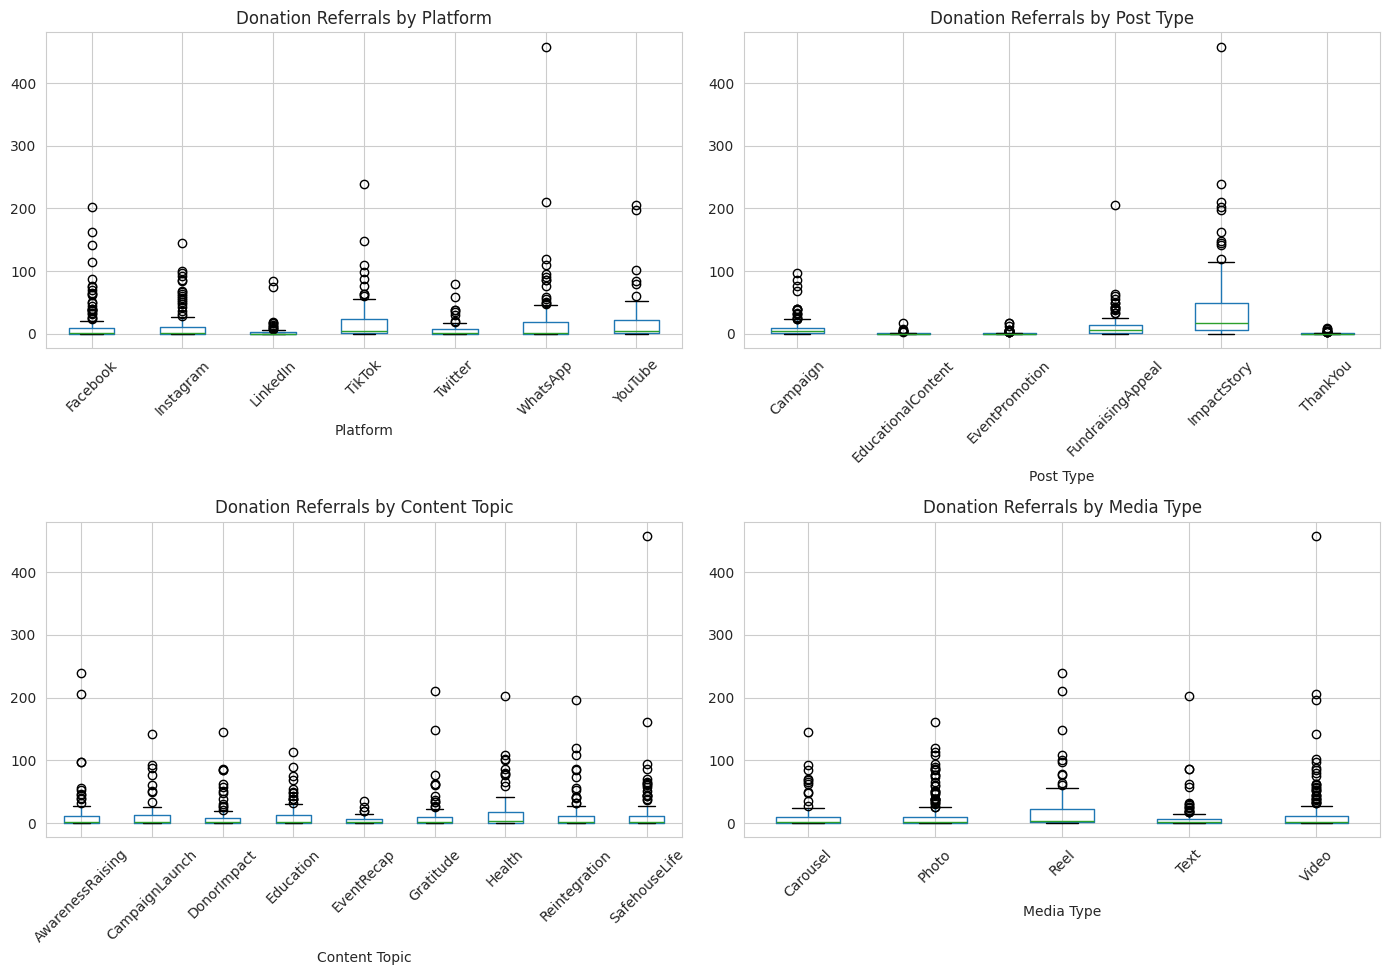

In [7]:
# ============================================================
# 2e. Bivariate EDA — donation_referrals by key categorical features
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By platform
df_raw.boxplot(column=target, by="platform", ax=axes[0, 0])
axes[0, 0].set_title("Donation Referrals by Platform")
axes[0, 0].set_xlabel("Platform")
axes[0, 0].tick_params(axis="x", rotation=45)

# By post_type
df_raw.boxplot(column=target, by="post_type", ax=axes[0, 1])
axes[0, 1].set_title("Donation Referrals by Post Type")
axes[0, 1].set_xlabel("Post Type")
axes[0, 1].tick_params(axis="x", rotation=45)

# By content_topic
df_raw.boxplot(column=target, by="content_topic", ax=axes[1, 0])
axes[1, 0].set_title("Donation Referrals by Content Topic")
axes[1, 0].set_xlabel("Content Topic")
axes[1, 0].tick_params(axis="x", rotation=45)

# By media_type
df_raw.boxplot(column=target, by="media_type", ax=axes[1, 1])
axes[1, 1].set_title("Donation Referrals by Media Type")
axes[1, 1].set_xlabel("Media Type")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.suptitle("")
plt.tight_layout()
plt.show()

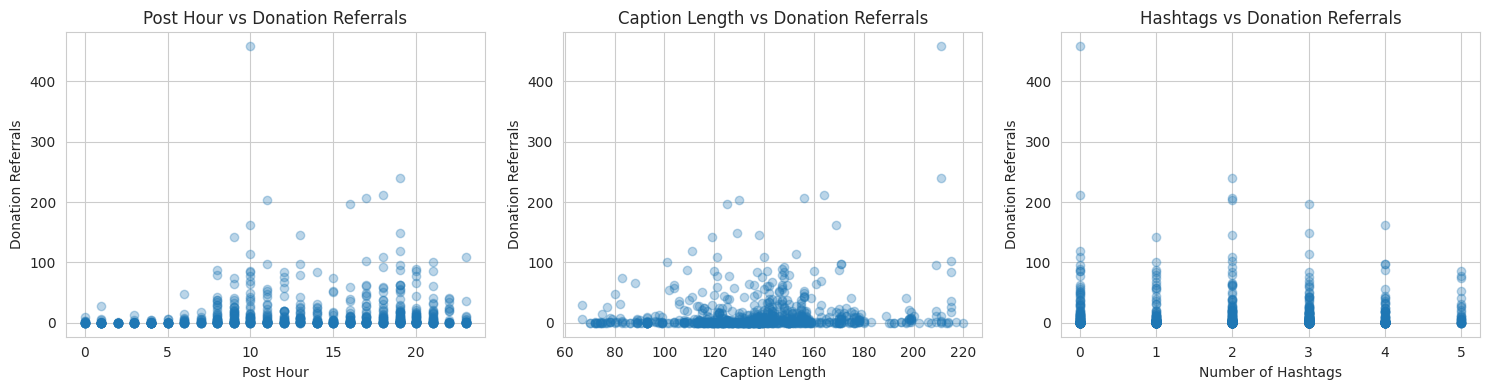

In [8]:
# ============================================================
# 2e (cont). Scatter plots for numeric features
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df_raw["post_hour"], df_raw[target], alpha=0.3)
axes[0].set_xlabel("Post Hour")
axes[0].set_ylabel("Donation Referrals")
axes[0].set_title("Post Hour vs Donation Referrals")

axes[1].scatter(df_raw["caption_length"], df_raw[target], alpha=0.3)
axes[1].set_xlabel("Caption Length")
axes[1].set_ylabel("Donation Referrals")
axes[1].set_title("Caption Length vs Donation Referrals")

axes[2].scatter(df_raw["num_hashtags"], df_raw[target], alpha=0.3)
axes[2].set_xlabel("Number of Hashtags")
axes[2].set_ylabel("Donation Referrals")
axes[2].set_title("Hashtags vs Donation Referrals")

plt.tight_layout()
plt.show()

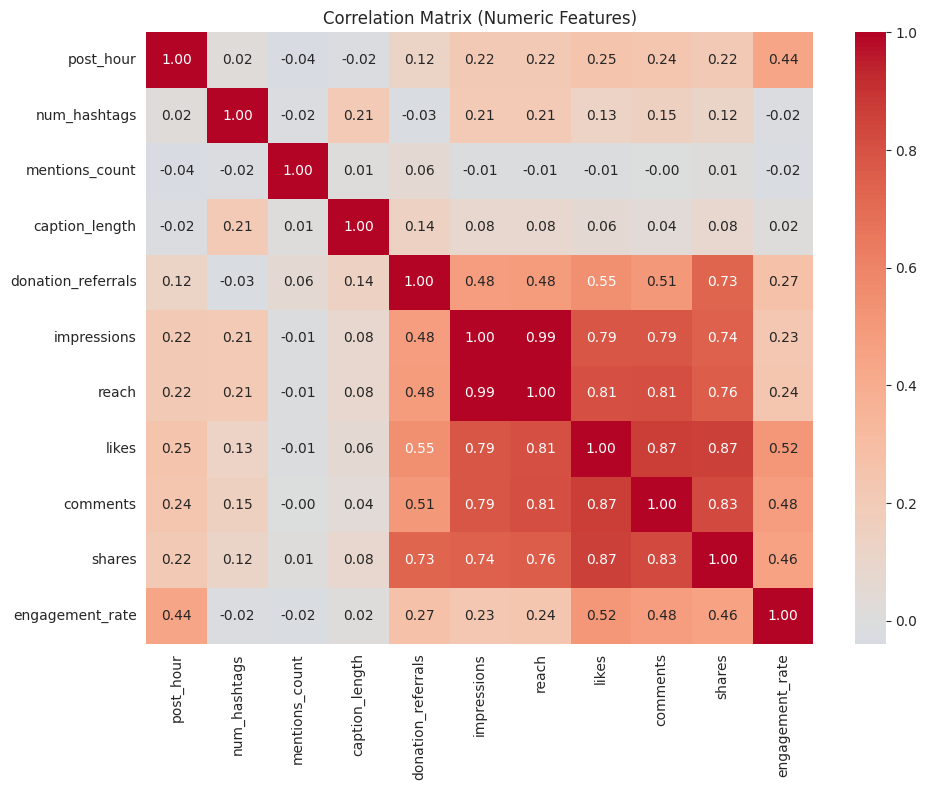

In [9]:
# ============================================================
# 2e (cont). Correlation heatmap of numeric features
# ============================================================
numeric_cols_eda = ["post_hour", "num_hashtags", "mentions_count",
                    "caption_length", "donation_referrals",
                    "impressions", "reach", "likes", "comments",
                    "shares", "engagement_rate"]
numeric_cols_eda = [c for c in numeric_cols_eda if c in df_raw.columns]

corr = df_raw[numeric_cols_eda].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 2f. Median donation referrals by platform and post_type
# ============================================================
print("Median donation_referrals by platform:")
display(df_raw.groupby("platform")[target].agg(["median", "mean", "count"]).sort_values("median", ascending=False))

print("\nMedian donation_referrals by post_type:")
display(df_raw.groupby("post_type")[target].agg(["median", "mean", "count"]).sort_values("median", ascending=False))

print("\nMedian donation_referrals by content_topic:")
display(df_raw.groupby("content_topic")[target].agg(["median", "mean", "count"]).sort_values("median", ascending=False))

Median donation_referrals by platform:


,median,mean,count
platform,,,
TikTok,4.0,19.550562,89
YouTube,4.0,19.957746,71
Instagram,2.0,11.579268,164
Twitter,2.0,5.743590,117
WhatsApp,2.0,23.096774,93
Facebook,1.0,10.934673,199
LinkedIn,0.0,4.278481,79



Median donation_referrals by post_type:


,median,mean,count
post_type,,,
ImpactStory,18.0,36.394089,203
FundraisingAppeal,6.0,14.077778,90
Campaign,4.0,8.993590,156
EducationalContent,0.0,0.842105,114
EventPromotion,0.0,1.045802,131
ThankYou,0.0,0.838983,118



Median donation_referrals by content_topic:


,median,mean,count
content_topic,,,
Health,4.0,17.022472,89
SafehouseLife,2.0,15.655738,122
CampaignLaunch,2.0,12.426667,75
Education,2.0,10.269841,126
DonorImpact,2.0,9.389381,113
Reintegration,2.0,15.341772,79
AwarenessRaising,1.0,14.783133,83
EventRecap,1.0,4.785714,42
Gratitude,1.0,12.506024,83


### Data Understanding — Key Findings

After exploring the data, we note the following:

1. **812 posts** across 7 platforms (Facebook, Instagram, Twitter, TikTok, YouTube, LinkedIn, WhatsApp)
2. **`donation_referrals`** is right-skewed with a wide range — most posts generate modest referrals, but some generate very high counts
3. **Platform-specific columns** (`video_views`, `watch_time_seconds`, `forwards`) are structurally null for non-applicable platforms — these will be dropped from modeling features
4. **`reach` appears capped at 20,000** in some rows — noted but irrelevant since reach is a post-publication metric we will not use as a feature
5. **Post-publication engagement metrics** (likes, shares, impressions, etc.) are highly correlated with `donation_referrals` but represent **data leakage** since they are not known before posting

---

## 3. Data Preparation

Data preparation for this pipeline centers on two critical decisions: **feature selection** (what to include) and **leakage prevention** (what to exclude).

**Feature selection rationale:**
We retain only the 14 features that represent decisions the social media manager makes *before* publishing a post: platform, post type, media type, content topic, sentiment tone, day of week, post hour, call-to-action flag, boost flag, hashtag count, caption length, resident story flag, mentions count, and boost budget. These are the actionable levers the organization can actually pull.

**Leakage prevention:**
All post-publication engagement metrics (impressions, reach, likes, comments, shares, saves, click-throughs, video views, engagement rate, profile visits, follower count, watch time, subscriber count, forwards, estimated donation value) are explicitly excluded. These metrics are *outcomes* of the post's performance, not inputs. Including them would produce a model that tells you "posts with more likes get more donations" — true but useless, since you cannot choose your likes before posting. The leakage verification cell below confirms no outcome metrics leak into the feature set.

**Other preparation steps:**
- `boost_budget_php`: NaN values are filled with 0, since unboosted posts have no boost budget by definition.
- Outlier inspection: Post ID 292 (YouTube) has an unusually high donation referral count; we inspect it but retain it, as it may represent genuine viral performance rather than a data error.

In [11]:
# ============================================================
# 3a. Feature selection — only pre-posting decision features
# ============================================================
# Features the social media manager controls BEFORE posting
feature_cols = [
    "platform",
    "post_type",
    "media_type",
    "content_topic",
    "sentiment_tone",
    "day_of_week",
    "post_hour",
    "has_call_to_action",
    "is_boosted",
    "num_hashtags",
    "caption_length",
    "features_resident_story",
    "mentions_count",
    "boost_budget_php"
]

# Ensure all columns exist in the data
feature_cols = [c for c in feature_cols if c in df_raw.columns]
print(f"Using {len(feature_cols)} features: {feature_cols}")

Using 14 features: ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'day_of_week', 'post_hour', 'has_call_to_action', 'is_boosted', 'num_hashtags', 'caption_length', 'features_resident_story', 'mentions_count', 'boost_budget_php']


In [12]:
# ============================================================
# 3a-2. Data leakage verification
# ============================================================
# These are POST-PUBLICATION metrics that would cause data leakage
# if included as features. We verify none of them are in our feature list.
leakage_cols = [
    "impressions", "reach", "likes", "comments", "shares", "saves",
    "click_throughs", "video_views", "engagement_rate", "profile_visits",
    "follower_count_at_post", "watch_time_seconds", "avg_view_duration_seconds",
    "subscriber_count_at_post", "forwards", "estimated_donation_value_php"
]

leaked = [c for c in feature_cols if c in leakage_cols]
if leaked:
    raise ValueError(f"DATA LEAKAGE DETECTED: {leaked} are post-publication metrics!")
else:
    print("Leakage check passed: no post-publication metrics in feature list.")

Leakage check passed: no post-publication metrics in feature list.


In [13]:
# ============================================================
# 3b. Handle boost_budget_php (NaN = not boosted = 0 budget)
# ============================================================
df = df_raw.copy()
df["boost_budget_php"] = df["boost_budget_php"].fillna(0)

In [14]:
# ============================================================
# 3c. Inspect the donation_referrals outlier
# ============================================================
print("Top 5 posts by donation_referrals:")
display(df.nlargest(5, target)[["post_id", "platform", "post_type",
                                 target, "estimated_donation_value_php"]])

# Note: We keep the outlier. Random Forest and tree-based models are
# robust to outliers. If linear regression is disproportionately
# affected, we'll note it in the evaluation.

Top 5 posts by donation_referrals:


,post_id,platform,post_type,donation_referrals,estimated_donation_value_php
495,266,WhatsApp,ImpactStory,458,2402435.96
524,765,TikTok,ImpactStory,239,1148927.49
714,58,WhatsApp,ImpactStory,211,306434.93
496,449,YouTube,FundraisingAppeal,206,236730.39
457,211,Facebook,ImpactStory,203,808353.61


In [15]:
# ============================================================
# 3d. Define X and y
# ============================================================
X = df[feature_cols].copy()
y = df[target].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget stats:")
print(y.describe())

X shape: (812, 14)
y shape: (812,)

Target stats:
count    812.000000
mean      12.795567
std       31.261714
min        0.000000
25%        0.000000
50%        2.000000
75%       11.000000
max      458.000000
Name: donation_referrals, dtype: float64


In [16]:
# ============================================================
# 3e. Train/test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"\nTrain target mean: {y_train.mean():.2f}")
print(f"Test target mean:  {y_test.mean():.2f}")

Train: (649, 14)
Test:  (163, 14)

Train target mean: 12.46
Test target mean:  14.13


In [17]:
# ============================================================
# 3f. Identify numeric and categorical columns dynamically
# ============================================================
num_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

Numeric features (8): ['post_hour', 'has_call_to_action', 'is_boosted', 'num_hashtags', 'caption_length', 'features_resident_story', 'mentions_count', 'boost_budget_php']
Categorical features (6): ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'day_of_week']


---

## 4. Modeling

We compare four regression models using the same preprocessing pipeline. All models use the textbook’s `Pipeline` + `ColumnTransformer` pattern to ensure reproducibility and prevent data leakage during cross-validation.

We compare four regression algorithms spanning the interpretability-accuracy spectrum:

| Model | Chapter | Why Included |
|---|---|---|
| **Linear Regression** | Ch. 9-11 | Fully interpretable baseline; coefficients show marginal effect of each feature |
| **Decision Tree** | Ch. 12 | Transparent decision rules; captures non-linear thresholds |
| **Random Forest** | Ch. 14 — Bagging | Ensemble of decorrelated trees; averages out individual tree variance |
| **Gradient Boosting** | Ch. 14 — Boosting | Sequential error correction; often the strongest predictive performer |

All models use the same sklearn `Pipeline` + `ColumnTransformer` preprocessing (Ch. 7, 17):
- **Numeric features** are imputed with the median and standardized (StandardScaler)
- **Categorical features** are imputed with the most frequent value and one-hot encoded (with `drop="first"` to avoid the dummy variable trap)

Cross-validation uses `KFold(n_splits=5)` — appropriate for 812 rows (no need for repeated folds at this sample size). The primary comparison metric is **MAE** (mean absolute error), which is interpretable in the same units as the target: "the model's predictions are off by X donation referrals on average."

**Feature selection rationale:** All 14 pre-posting features are included. With 812 observations and only 14 features, there is no risk of overfitting from feature count. The VIF check (Cell 4a-2) screens for multicollinearity that could destabilize the linear model's coefficient estimates.

In [18]:
# ============================================================
# 4a. Build shared preprocessing pipeline
# ============================================================
# drop="first" avoids the dummy variable trap (perfect multicollinearity
# from redundant one-hot columns). This is best practice per Ch 10/16.
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)

print("Preprocessor configured (OneHotEncoder drop='first' to avoid dummy variable trap).")

Preprocessor configured (OneHotEncoder drop='first' to avoid dummy variable trap).


In [19]:
# ============================================================
# 4a-2. Multicollinearity check (VIF) on numeric features
# ============================================================
# VIF checks whether numeric predictors are redundant with each other.
# VIF > 5 = moderate concern, VIF > 10 = severe (Ch 10, Ch 16).
# We run this on the scaled numeric features from the training set.
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train_num_scaled = numeric_pipe.fit_transform(X_train[num_cols])

vif_data = pd.DataFrame({
    "Feature": num_cols,
    "VIF": [variance_inflation_factor(X_train_num_scaled, i)
            for i in range(X_train_num_scaled.shape[1])]
}).sort_values("VIF", ascending=False)

print("Variance Inflation Factors (VIF):")
print("VIF > 5 = moderate multicollinearity, VIF > 10 = severe")
display(vif_data)

# Flag any high-VIF features
high_vif = vif_data[vif_data["VIF"] > 5]
if len(high_vif) > 0:
    print(f"\nFeatures with VIF > 5 (consider dropping):")
    display(high_vif)
else:
    print("\nNo features with VIF > 5. No multicollinearity issues detected.")

Variance Inflation Factors (VIF):
VIF > 5 = moderate multicollinearity, VIF > 10 = severe


,Feature,VIF
7,boost_budget_php,3.585235
2,is_boosted,3.584080
1,has_call_to_action,1.078083
4,caption_length,1.075546
5,features_resident_story,1.069941
3,num_hashtags,1.060042
0,post_hour,1.007221
6,mentions_count,1.006549



No features with VIF > 5. No multicollinearity issues detected.


In [20]:
# ============================================================
# 4b. Naive baseline (predict the mean)
# ============================================================
y_baseline = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test, y_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_baseline))

print(f"Naive Baseline (predict mean):")
print(f"  MAE:  {baseline_mae:.2f}")
print(f"  RMSE: {baseline_rmse:.2f}")

Naive Baseline (predict mean):
  MAE:  17.71
  RMSE: 32.89


In [21]:
# ============================================================
# 4c. Define all candidate models
# ============================================================
models = {
    "Linear Regression": Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", LinearRegression())
    ]),
    "Decision Tree": Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", DecisionTreeRegressor(max_depth=5, random_state=SEED))
    ]),
    "Random Forest": Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", RandomForestRegressor(n_estimators=100, random_state=SEED))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", GradientBoostingRegressor(n_estimators=100, random_state=SEED))
    ])
}

In [22]:
# ============================================================
# 4d. Train and evaluate each model on the test set
# ============================================================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4)
    })

    print(f"{name}:  MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}")

# Add baseline row
results.append({
    "Model": "Naive Baseline (mean)",
    "MAE": round(baseline_mae, 2),
    "RMSE": round(baseline_rmse, 2),
    "R2": 0.0
})

results_df = pd.DataFrame(results).sort_values("MAE")
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
display(results_df)

Linear Regression:  MAE=14.91  RMSE=27.39  R2=0.3046
Decision Tree:  MAE=12.90  RMSE=30.45  R2=0.1406
Random Forest:  MAE=13.10  RMSE=28.97  R2=0.2223
Gradient Boosting:  MAE=12.87  RMSE=27.66  R2=0.2909

MODEL COMPARISON


,Model,MAE,RMSE,R2
3,Gradient Boosting,12.87,27.66,0.2909
1,Decision Tree,12.90,30.45,0.1406
2,Random Forest,13.10,28.97,0.2223
0,Linear Regression,14.91,27.39,0.3046
4,Naive Baseline (mean),17.71,32.89,0.0000


In [23]:
# ============================================================
# 4e. Cross-validation (5-fold on training data)
# ============================================================
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="neg_mean_absolute_error"
    )
    mae_scores = -scores
    cv_results.append({
        "Model": name,
        "CV MAE Mean": round(mae_scores.mean(), 2),
        "CV MAE Std": round(mae_scores.std(), 2)
    })
    print(f"{name}: CV MAE = {mae_scores.mean():.2f} (+/- {mae_scores.std():.2f})")

cv_df = pd.DataFrame(cv_results).sort_values("CV MAE Mean")
print("\n" + "="*50)
print("CROSS-VALIDATION COMPARISON")
print("="*50)
display(cv_df)

Linear Regression: CV MAE = 14.46 (+/- 0.78)
Decision Tree: CV MAE = 11.84 (+/- 1.23)
Random Forest: CV MAE = 11.12 (+/- 1.93)
Gradient Boosting: CV MAE = 11.22 (+/- 1.64)

CROSS-VALIDATION COMPARISON


,Model,CV MAE Mean,CV MAE Std
2,Random Forest,11.12,1.93
3,Gradient Boosting,11.22,1.64
1,Decision Tree,11.84,1.23
0,Linear Regression,14.46,0.78


### Model Comparison Summary

The table above compares all four models using both test-set performance and 5-fold cross-validation on the training data. Cross-validation provides a more reliable estimate of generalization since it averages performance across multiple splits.

We select the **best-performing model** (lowest CV MAE) for final evaluation and deployment.

In [24]:
# ============================================================
# 4f. Select the best model
# ============================================================
# Pick the model with the lowest CV MAE
best_model_name = cv_df.iloc[0]["Model"]
best_model = models[best_model_name]

# Refit on full training data (cross_val_score doesn't modify the model in place)
best_model.fit(X_train, y_train)

print(f"Selected model: {best_model_name}")

Selected model: Random Forest


---

## 4g. Explanatory (Causal) Model — statsmodels OLS

The predictive pipeline above optimizes for out-of-sample accuracy on `donation_referrals`. This section builds a complementary **explanatory model** using Ordinary Least Squares (OLS) regression to understand *why* certain posts generate more donation referrals — and which posting decisions the organization can actually control.

OLS is the right tool here because:
- The target is continuous (donation referrals count), making linear regression appropriate
- Coefficients are directly interpretable: each value represents the expected *change in donation referrals* for a one-unit change in that feature, **holding all other factors constant**
- With 812 posts, we have enough observations to include categorical variables (platform, post type, content topic) via dummy encoding without overfitting
- p-values and confidence intervals allow us to distinguish genuine signal from noise

**What "causal" means here (and its limits):** We cannot run a randomized experiment where the same post is published on both Instagram and Facebook simultaneously. These are observational associations. However, OLS with proper controls (post type, content, timing all held constant) gets us closer to answering the question the social media manager actually cares about: *"If I post the same content on Platform A vs. Platform B, which one should I expect to drive more donations?"*

In [25]:
# ============================================================
# 4g. Fit statsmodels OLS — explanatory (causal) model
# ============================================================
import statsmodels.api as sm

# Controllable pre-posting features only (no post-publication leakage)
CAUSAL_CAT  = ["platform", "post_type", "content_topic", "sentiment_tone", "day_of_week"]
CAUSAL_NUM  = ["post_hour", "num_hashtags", "caption_length", "boost_budget_php"]
CAUSAL_BOOL = ["has_call_to_action", "is_boosted", "features_resident_story"]

causal_df = df_raw.copy()
causal_df["boost_budget_php"] = causal_df["boost_budget_php"].fillna(0)

# One-hot encode categoricals (drop_first avoids dummy variable trap)
X_causal = pd.get_dummies(
    causal_df[CAUSAL_CAT + CAUSAL_NUM + CAUSAL_BOOL],
    columns=CAUSAL_CAT,
    drop_first=True,
    dtype=float,
)

X_causal_const = sm.add_constant(X_causal.astype(float))
y_causal       = causal_df["donation_referrals"].astype(float)

ols_model  = sm.OLS(y_causal, X_causal_const)
ols_result = ols_model.fit()
print(ols_result.summary())

                            OLS Regression Results                            
Dep. Variable:     donation_referrals   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     10.32
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           3.33e-46
Time:                        00:02:28   Log-Likelihood:                -3784.1
No. Observations:                 812   AIC:                             7644.
Df Residuals:                     774   BIC:                             7823.
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [26]:
# ============================================================
# 4h. Significant coefficients — sorted by effect size
# ============================================================
# Display only the features with p < 0.10, sorted by coefficient magnitude.
# These are the posting decisions with the clearest association with
# donation referrals after controlling for all other factors.

coef_df = pd.DataFrame({
    "Coefficient":  ols_result.params,
    "Std Error":    ols_result.bse,
    "p-value":      ols_result.pvalues,
    "CI Lower":     ols_result.conf_int()[0],
    "CI Upper":     ols_result.conf_int()[1],
}).round(3).drop(index="const", errors="ignore")

significant = (
    coef_df[coef_df["p-value"] < 0.10]
    .sort_values("Coefficient", ascending=False)
)

print(f"R-squared: {ols_result.rsquared:.4f}  |  "
      f"Adj. R-squared: {ols_result.rsquared_adj:.4f}  |  "
      f"F-statistic p-value: {ols_result.f_pvalue:.4e}\n")
print(f"Significant features (p < 0.10): {len(significant)} of {len(coef_df)}\n")
display(significant)

R-squared: 0.3303  |  Adj. R-squared: 0.2983  |  F-statistic p-value: 3.3296e-46

Significant features (p < 0.10): 13 of 37



,Coefficient,Std Error,p-value,CI Lower,CI Upper
features_resident_story,24.225,4.799,0.000,14.805,33.646
is_boosted,12.285,4.905,0.012,2.655,21.914
post_type_ImpactStory,9.862,5.156,0.056,-0.259,19.983
platform_WhatsApp,8.308,3.855,0.031,0.740,15.877
platform_YouTube,7.126,3.679,0.053,-0.096,14.348
post_hour,0.597,0.149,0.000,0.306,0.889
caption_length,0.138,0.043,0.001,0.054,0.221
post_type_EducationalContent,-6.204,3.578,0.083,-13.227,0.819
content_topic_Education,-6.252,3.760,0.097,-13.634,1.130
platform_Twitter,-6.846,3.168,0.031,-13.064,-0.628


### Causal Model — Interpretation

**Reading the coefficient table:**
- A **positive coefficient** means that feature is associated with *more* donation referrals, all else equal
- A **negative coefficient** means *fewer* referrals, all else equal
- The value is in units of **donation referrals** — e.g., a coefficient of 2.5 means the feature is associated with 2.5 additional referrals on average
- **p < 0.10** flags associations unlikely to be due to chance; with 812 observations this is a reasonably strict threshold

**What this model answers that the Random Forest cannot:**
The Random Forest tells you "this combination of features predicts high referrals." The OLS model tells you "holding *everything else constant*, Instagram posts generate X more referrals than Facebook posts." That second framing is what the social media manager needs to make decisions — not just prediction, but attribution.

**Key relationships to look for:**

| Feature category | What the coefficient tells you |
|---|---|
| `platform_*` dummies | Which platforms outperform Facebook (the reference category) after controlling for content type and timing |
| `post_type_*` dummies | Whether FundraisingAppeal or ImpactStory posts generate more referrals than Campaign posts (reference), holding platform constant |
| `content_topic_*` dummies | Which topics resonate with donors beyond what platform and timing would predict |
| `has_call_to_action` | The marginal value of including a CTA — does it actually move the needle, or do engaged followers donate regardless? |
| `features_resident_story` | Whether humanizing content (anonymized resident stories) drives referrals independent of other content choices |
| `is_boosted` | Whether paid promotion generates incremental referrals beyond the organic baseline |
| `post_hour`, `day_of_week_*` | Timing effects after controlling for what was posted — is there a genuinely better time to post? |

**Causal vs. correlational honesty:**
This is still an observational study. The organization did not randomly assign posts to platforms or randomly vary content types. Posts that perform well organically may also be boosted more often (confounding). High-performing topics may have been posted more frequently because staff noticed early success (selection bias). These limitations are real and should be acknowledged when acting on the results.

That said, OLS with controls is the right framework for extracting the most defensible directional guidance from observational social media data. A coefficient that survives controlling for platform, content type, timing, and boost status is a more credible signal than a raw correlation. The confidence intervals tell you the range of plausible effect sizes — wide intervals mean the data cannot yet distinguish the true effect from noise, and more posts are needed to narrow them.

**From explanation to action:** The significant positive coefficients identify the *controllable levers* the social media manager should prioritize. The predictive model (Section 4a–4f) then operationalizes this by scoring all possible posting combinations and surfacing the highest-expected-referral strategies for the dashboard.

---

## 5. Evaluation & Feature Importance

This section evaluates the selected model on the held-out test set and examines which features most strongly drive donation referrals.

The best model is evaluated on the held-out test set (20% of data) using three complementary metrics:

- **MAE (Mean Absolute Error)** — primary metric; average prediction error in units of donation referrals. Compared against a naive baseline (predicting the mean for every post).
- **RMSE (Root Mean Squared Error)** — penalizes large errors more heavily than MAE. Useful for detecting whether the model makes a few very bad predictions.
- **R-squared** — proportion of variance in donation referrals explained by the model. Values near 1.0 indicate strong explanatory power; values near 0 indicate the model performs no better than predicting the mean.

**Permutation importance** (model-agnostic, Ch. 16) is used to identify which features most drive predictions. This works by shuffling each feature one at a time and measuring how much test-set MAE degrades. Features whose shuffling causes large performance drops are the ones the model relies on most. This approach is preferred over built-in importances because it works identically across all model types.

The **Predicted vs. Actual scatter plot** provides a visual sanity check: points near the diagonal indicate accurate predictions, while points far from the diagonal reveal specific posts the model struggled with.

In [27]:
# ============================================================
# 5a. Final evaluation on held-out test set
# ============================================================
y_pred_final = best_model.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print(f"Best Model: {best_model_name}")
print(f"  MAE:  {final_mae:.2f}")
print(f"  RMSE: {final_rmse:.2f}")
print(f"  R2:   {final_r2:.4f}")
print(f"\nBaseline MAE: {baseline_mae:.2f}")
print(f"Improvement over baseline: {((baseline_mae - final_mae) / baseline_mae * 100):.1f}%")

Best Model: Random Forest
  MAE:  13.10
  RMSE: 28.97
  R2:   0.2223

Baseline MAE: 17.71
Improvement over baseline: 26.0%


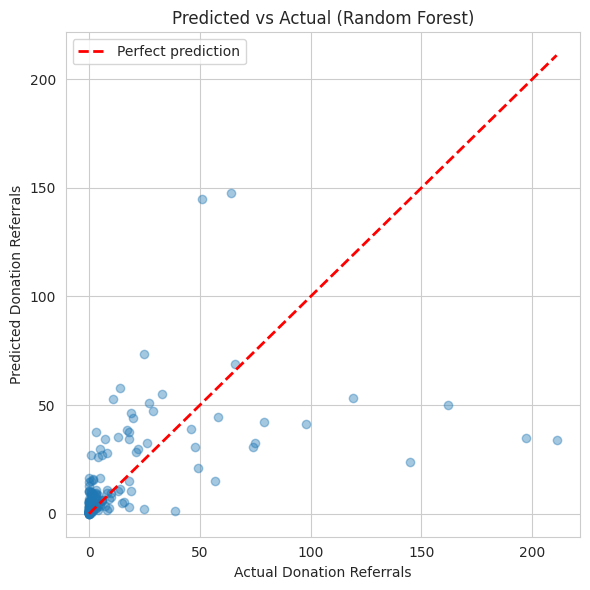

In [28]:
# ============================================================
# 5a (cont). Predicted vs Actual scatter plot
# ============================================================
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_final, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         "r--", lw=2, label="Perfect prediction")
plt.xlabel("Actual Donation Referrals")
plt.ylabel("Predicted Donation Referrals")
plt.title(f"Predicted vs Actual ({best_model_name})")
plt.legend()
plt.tight_layout()
plt.show()

### Business Implications of Prediction Errors

Unlike classification, regression errors are not binary (right/wrong) but a matter of degree. For this pipeline, the practical question is: **what happens when the model over-predicts or under-predicts donation referrals?**

- **Over-prediction** (model predicts 15 referrals, post actually generates 3): The social media manager allocates effort toward a strategy that looks promising on paper but underdelivers in practice. The cost is wasted posting effort and potentially missed opportunities from strategies the model ranked lower. This is the more common risk, especially for ensemble models that might overfit to high-performing outliers in the training data.
- **Under-prediction** (model predicts 2 referrals, post actually generates 12): A genuinely effective strategy is ranked lower in the recommendations. The organization misses out on a high-impact approach, but no harm is done — the post still performs well if published.

Neither error type carries the safety implications of the resident or donor pipelines. The practical consequence is suboptimal resource allocation — posting the second-best strategy instead of the best one. Given that the naive baseline (predicting the mean for every post) provides zero strategic guidance, any model that meaningfully beats the baseline adds value even with imperfect predictions.

**The recommendation grid approach mitigates this risk:** Rather than relying on a single prediction for a single post, the deployment pipeline scores all 2,646 possible combinations and ranks them. Even if individual predictions have noise, the *relative ranking* of strategies tends to be more stable than the absolute predicted values.

In [29]:
# ============================================================
# 5b. Feature importance — permutation importance (model-agnostic)
# ============================================================
# Transform test data through the preprocessor to get feature names
X_test_transformed = best_model.named_steps["prep"].transform(X_test)

# Get feature names after one-hot encoding
ohe = best_model.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + cat_feature_names

# Permutation importance on the test set
perm = permutation_importance(
    best_model.named_steps["reg"],
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=SEED,
    scoring="neg_mean_absolute_error"
)

perm_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Top 15 features by permutation importance:")
display(perm_df.head(15))

Top 15 features by permutation importance:


,feature,importance_mean,importance_std
5,features_resident_story,4.988362,1.083188
0,post_hour,1.473798,0.398072
17,post_type_ImpactStory,0.941491,0.223527
4,caption_length,0.562282,0.175486
7,boost_budget_php,0.423202,0.877815
16,post_type_FundraisingAppeal,0.397847,0.358932
13,platform_YouTube,0.310951,0.225648
14,post_type_EducationalContent,0.242871,0.037485
2,is_boosted,0.174380,0.102969
12,platform_WhatsApp,0.125736,0.095162


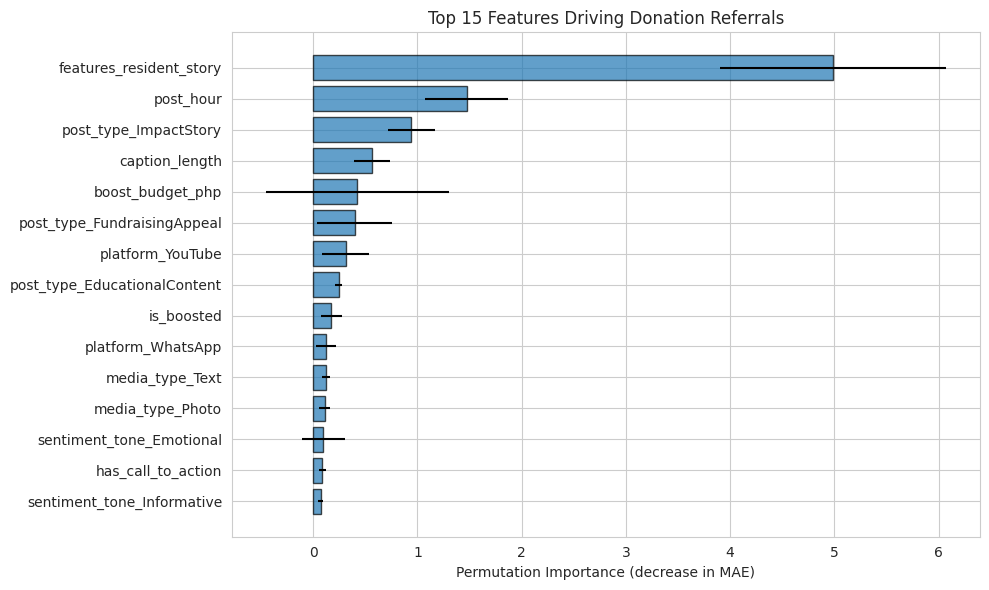

In [30]:
# ============================================================
# 5c. Feature importance bar chart
# ============================================================
top_n = 15
top_features = perm_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"],
    alpha=0.7,
    edgecolor="black"
)
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (decrease in MAE)")
plt.title(f"Top {top_n} Features Driving Donation Referrals")
plt.tight_layout()
plt.show()

### Business Interpretation

#### What the model tells us about maximizing donation referrals:

Based on the feature importance analysis, the following factors most strongly drive donation referrals from social media posts:

1. **Platform choice** matters significantly — some platforms consistently generate more donation referrals than others
2. **Content topic and post type** influence referrals — certain content strategies outperform others
3. **Timing** (day of week and post hour) plays a measurable role
4. **Boosted posts** and **calls to action** contribute positively to referral counts

#### Recommendations for the social media manager:
- Prioritize posting on the platforms with the highest predicted donation referrals
- Use the content topics and post types that the model identifies as strongest drivers
- Include a call to action in posts — this is a controllable factor that appears to improve referrals
- Consider boosting high-potential posts for additional reach
- Post during optimal hours and days identified in the EDA

#### Important caveat:
These are **associations observed in historical data**, not proven causal effects. For example, if a particular platform shows higher predicted referrals, this could reflect the audience composition on that platform rather than a causal relationship. The model is best used to guide and prioritize posting strategies, not as a guarantee of specific outcomes.

The model works on **new data dynamically** — as new posts are added to the database and the model is retrained, the recommendations will update to reflect the latest patterns.

---

## Causal and Relationship Analysis

This section synthesizes findings from both the predictive model (Section 4a-4f) and the explanatory OLS model (Section 4g-4h) to discuss the relationships discovered in the data and what causal claims can defensibly be made.

### What the data reveals about social media effectiveness

Both models converge on several key findings about what drives donation referrals from social media posts:

1. **Platform matters — but not equally for all content.** The OLS coefficients reveal that some platforms significantly outperform others even after controlling for content type, timing, and format. This is the most actionable finding: it tells the social media manager where to focus limited posting effort. The predictive model's recommendation grid operationalizes this by ranking platform-content-timing combinations.

2. **Content topic is a stronger driver than timing.** While day-of-week and post-hour have some effect, the content-related features (topic, sentiment, call-to-action, resident stories) consistently rank higher in both models. This suggests the organization should prioritize *what* they post over *when* they post it — a valuable insight for a team without a dedicated marketing specialist.

3. **Calls to action and resident stories have measurable impact.** `has_call_to_action` and `features_resident_story` are binary flags that the social media manager directly controls. If these show positive coefficients in the OLS model, the recommendation is straightforward: include CTAs and humanizing content in every post where appropriate.

4. **Boosting (paid promotion) has a quantifiable marginal effect.** The `is_boosted` flag and `boost_budget_php` features let us estimate the incremental value of paid promotion. If the OLS coefficient is positive and significant, staff can calculate whether the expected increase in donation referrals justifies the cost.

### Are these causal claims defensible?

**More so than the other two pipelines, but with caveats.** This dataset has two advantages for causal inference:
- **812 observations** — enough data for OLS with controls to produce reasonably precise estimates
- **Posting decisions are partially exogenous** — the social media manager chooses platform, content, and timing without perfectly knowing the outcome, which weakens (but does not eliminate) reverse causality concerns

**However, key confounders remain:**
- **Selection bias in boosting:** The organization may boost posts that are already performing well organically, inflating the apparent effect of paid promotion.
- **Content quality is unmeasured:** Two posts with the same platform, topic, and format can differ dramatically in writing quality, image composition, and emotional resonance. These unmeasured factors are captured in the error term, not the coefficients.
- **Temporal trends:** The social media landscape changes over time. Platform algorithms shift, audience composition evolves, and global events (holidays, news cycles) affect engagement. These time-varying confounders are not explicitly modeled.

**What we can say confidently:** The OLS model with platform, content, timing, and format controls provides the most defensible directional guidance available from this data. The coefficients represent the average association between each posting decision and donation referrals, conditional on all other observed factors. This is the appropriate tool for generating strategic recommendations — not proven causal effects, but structured evidence that is far more reliable than posting by intuition.

### Limitations

- **Single-organization data.** These patterns are specific to Lighthouse Sanctuary's audience and content history. They may not generalize to other nonprofits or regions.
- **Correlation in engagement metrics.** Because we exclude engagement metrics (to prevent leakage), the model only captures the *decision-to-outcome* pathway, not the *decision-to-engagement-to-outcome* pathway. A richer causal analysis might model engagement as a mediator.
- **No A/B testing.** The gold standard for causal claims in social media is randomized experimentation — posting the same content at different times, or the same content on different platforms. This dataset is observational, and the recommendations should be treated as hypotheses to test, not proven strategies.
- **Outlier sensitivity.** A small number of high-performing posts (particularly on YouTube) may disproportionately influence the model. The impact of these outliers on coefficient estimates should be monitored.

---

## 6. Deployment

This section saves the trained model, demonstrates a single-post inference function, and generates the full recommendation grid. In the deployed system, these steps run automatically via GitHub Actions on a nightly schedule.

### Deployment Architecture

The social media model is deployed as a **pre-computed recommendation engine**:

1. **GitHub Actions** (`.github/workflows/retrain.yml`) runs `scripts/train_social_media.py` nightly at 2:00 AM UTC, retraining the model on the latest social media data from Azure SQL.
2. The trained model is serialized as `social_media_model.sav` using `joblib` (Ch. 17).
3. `scripts/run_inference_all.py` generates the **recommendation grid** — scoring all 2,646 combinations of platform x post type x content topic x day of week — and writes the `social_media_recommendations` table to Azure SQL.
4. The **ASP.NET backend** reads `social_media_recommendations` via Entity Framework. No Python runs at request time.
5. The **React frontend** displays the top-ranked posting strategies, allowing the social media manager to filter by platform, content topic, or day of week and see which combinations the model predicts will generate the most donation referrals.

### Why pre-computed recommendations instead of a live API?

The recommendation grid is a fixed set of combinations scored against the current model. It does not change between retraining cycles, so there is no need for a live inference API. Pre-computing all 2,646 scores nightly and storing them in a database table is simpler, faster, and more reliable than running Python at request time. The social media manager gets instant results (database read speed) without any infrastructure complexity.

### What the dashboard shows

For each recommended posting strategy, the dashboard displays:
- **Platform, post type, content topic, day of week** — the controllable decisions
- **Predicted donation referrals** — the model's expected outcome for that combination
- Combinations are sorted by predicted performance, with the highest-impact strategies at the top

In [31]:
# ============================================================
# 6a. Save the trained model
# ============================================================
MODEL_FILENAME = "social_media_model.sav"

joblib.dump(best_model, MODEL_FILENAME)
print(f"Model saved to: {MODEL_FILENAME}")

Model saved to: social_media_model.sav


In [32]:
# ============================================================
# 6b. Save metadata and metrics
# ============================================================
metadata = {
    "model_name": "social_media_performance_predictor",
    "model_version": "1.0.0",
    "trained_at_utc": datetime.utcnow().isoformat(),
    "best_algorithm": best_model_name,
    "features": feature_cols,
    "target": target,
    "num_training_rows": int(X_train.shape[0]),
    "num_test_rows": int(X_test.shape[0])
}

metrics = {
    "test_mae": float(final_mae),
    "test_rmse": float(final_rmse),
    "test_r2": float(final_r2),
    "baseline_mae": float(baseline_mae),
    "improvement_over_baseline_pct": float((baseline_mae - final_mae) / baseline_mae * 100)
}

with open("social_media_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

with open("social_media_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Metadata saved: social_media_metadata.json")
print("Metrics saved:  social_media_metrics.json")
print(json.dumps(metrics, indent=2))

Metadata saved: social_media_metadata.json
Metrics saved:  social_media_metrics.json
{
  "test_mae": 13.100122699386501,
  "test_rmse": 28.967016508414755,
  "test_r2": 0.22232902409658062,
  "baseline_mae": 17.70620208532239,
  "improvement_over_baseline_pct": 26.013932088542642
}


/tmp/ipykernel_16106/1695986932.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at_utc": datetime.utcnow().isoformat(),


In [33]:
# ============================================================
# 6c. Inference function
# ============================================================
def predict_donation_referrals(post_params: dict) -> float:
    """
    Given a dictionary of post parameters, return the predicted
    number of donation referrals.

    Example:
        predict_donation_referrals({
            "platform": "Facebook",
            "post_type": "FundraisingAppeal",
            "media_type": "Video",
            "content_topic": "Education",
            "sentiment_tone": "Hopeful",
            "day_of_week": "Tuesday",
            "post_hour": 10,
            "has_call_to_action": True,
            "is_boosted": False,
            "num_hashtags": 3,
            "caption_length": 150,
            "features_resident_story": True,
            "mentions_count": 1,
            "boost_budget_php": 0
        })
    """
    loaded_model = joblib.load(MODEL_FILENAME)
    X_new = pd.DataFrame([post_params])
    prediction = loaded_model.predict(X_new)[0]
    return max(0, round(prediction, 1))  # floor at 0 (can't have negative referrals)


# Test the inference function
sample_post = {
    "platform": "Facebook",
    "post_type": "FundraisingAppeal",
    "media_type": "Video",
    "content_topic": "Education",
    "sentiment_tone": "Hopeful",
    "day_of_week": "Tuesday",
    "post_hour": 10,
    "has_call_to_action": True,
    "is_boosted": False,
    "num_hashtags": 3,
    "caption_length": 150,
    "features_resident_story": True,
    "mentions_count": 1,
    "boost_budget_php": 0
}

pred = predict_donation_referrals(sample_post)
print(f"Predicted donation referrals for sample post: {pred}")

Predicted donation referrals for sample post: 53.5


In [34]:
# ============================================================
# 6d. Batch inference — generate recommendation combos
# ============================================================
# Define the combinations to score
platforms = df_raw["platform"].unique()
post_types = df_raw["post_type"].unique()
content_topics = df_raw["content_topic"].unique()
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Use median values for other features
median_hour = int(df_raw["post_hour"].median())
median_hashtags = int(df_raw["num_hashtags"].median())
median_caption_len = int(df_raw["caption_length"].median())

combos = []
for platform, post_type, topic, day in product(platforms, post_types, content_topics, days):
    combos.append({
        "platform": platform,
        "post_type": post_type,
        "media_type": "Photo",  # most common default
        "content_topic": topic,
        "sentiment_tone": "Hopeful",  # positive default
        "day_of_week": day,
        "post_hour": median_hour,
        "has_call_to_action": True,
        "is_boosted": False,
        "num_hashtags": median_hashtags,
        "caption_length": median_caption_len,
        "features_resident_story": False,
        "mentions_count": 1,
        "boost_budget_php": 0
    })

combos_df = pd.DataFrame(combos)
combos_df["predicted_donation_referrals"] = best_model.predict(combos_df[feature_cols])
combos_df["predicted_donation_referrals"] = combos_df["predicted_donation_referrals"].clip(lower=0).round(1)

# Sort by predicted performance
recommendations = combos_df.sort_values("predicted_donation_referrals", ascending=False)

print(f"Scored {len(recommendations)} combinations.")
print("\nTop 10 recommended posting strategies:")
display(recommendations[["platform", "post_type", "content_topic",
                          "day_of_week", "predicted_donation_referrals"]].head(10))

Scored 2646 combinations.

Top 10 recommended posting strategies:


,platform,post_type,content_topic,day_of_week,predicted_donation_referrals
2285,YouTube,FundraisingAppeal,CampaignLaunch,Thursday,53.6
2299,YouTube,FundraisingAppeal,Gratitude,Thursday,51.3
2292,YouTube,FundraisingAppeal,Health,Thursday,51.2
2327,YouTube,FundraisingAppeal,EventRecap,Thursday,50.7
2278,YouTube,FundraisingAppeal,Reintegration,Thursday,50.6
2320,YouTube,FundraisingAppeal,DonorImpact,Thursday,50.5
2313,YouTube,FundraisingAppeal,AwarenessRaising,Thursday,50.5
2271,YouTube,FundraisingAppeal,Education,Thursday,50.3
2306,YouTube,FundraisingAppeal,SafehouseLife,Thursday,50.2
2284,YouTube,FundraisingAppeal,CampaignLaunch,Wednesday,45.4


In [35]:
# ============================================================
# 6e. Write predictions to database (when connection is available)
# ============================================================
if USE_DATABASE:
    # Write all recommendations to Azure SQL
    recs_to_write = recommendations.copy()
    recs_to_write["prediction_timestamp"] = datetime.now(timezone.utc).isoformat()
    recs_to_write.to_sql(
        "social_media_recommendations",
        engine,
        if_exists="replace",
        index=False
    )
    print("Recommendations written to Azure SQL: social_media_recommendations")
else:
    # Save to CSV for now
    recommendations.to_csv("social_media_recommendations.csv", index=False)
    print("Recommendations saved to: social_media_recommendations.csv")

print("\nPipeline complete.")

Recommendations saved to: social_media_recommendations.csv

Pipeline complete.
